# NAVYA — Data Preprocessing

This notebook transforms only a copy of the raw data into a clean intermediate dataset. It does not engineer the final derived feature set or fit an imputer.

## 1. Imports, paths, and raw load

This cell locates the source CSV and output directory. The source is read-only throughout the workflow.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
ROOT = ROOT if (ROOT / "data").exists() else ROOT.parent
RAW_PATH = ROOT / "data" / "calibrated_menstrual_cycle_ml_dataset.csv"
OUT = ROOT / "processed_data"
OUT.mkdir(exist_ok=True)
raw = pd.read_csv(RAW_PATH)
clean = raw.copy()
print("Raw shape:", raw.shape)

Raw shape: (20000, 30)


## 2. Preserve longitudinal grouping

No explicit woman ID exists, so this cell reconstructs the documented ordered 20-window blocks. It asserts the expected record count before adding fields used exclusively for group splitting.

In [3]:
assert len(clean) % 20 == 0, "Cannot safely reconstruct 20-row woman blocks."
clean["woman_id"] = np.arange(len(clean)) // 20 + 1
clean["window_index"] = np.arange(len(clean)) % 20 + 1
print(
    "Women:",
    clean.woman_id.nunique(),
    " rows per woman:",
    clean.groupby("woman_id").size().unique(),
)

Women: 1000  rows per woman: [20]


## 3. Contract renaming and categorical mappings

The target is renamed for the model contract. Stress, exercise, and medication are mapped exactly to app-compatible numeric encodings; `Not Sure` deliberately becomes missing for later training-set median imputation.

In [4]:
clean = clean.rename(columns={"next_cycle_length": "next_cycle_length_days"})
stress_map = {"Very Low": 1, "Low": 2, "Moderate": 3, "High": 4, "Very High": 5}
exercise_map = {"Never": 0, "1-2 days/week": 1, "3-4 days/week": 2, "5+ days/week": 2}
medication_map = {"No": 0, "Yes": 1, "Not Sure": np.nan}
clean["stress_level"] = clean["stress"].map(stress_map)
clean["exercise_frequency"] = clean["exercise"].map(exercise_map)
clean["uses_medication_or_contraceptive"] = clean["medication_contraceptive"].map(
    medication_map
)
print(
    "Unmapped stress:",
    clean.loc[clean.stress.notna() & clean.stress_level.isna(), "stress"].unique(),
)
print(
    "Unmapped exercise:",
    clean.loc[
        clean.exercise.notna() & clean.exercise_frequency.isna(), "exercise"
    ].unique(),
)
print(
    "Unmapped medication:",
    clean.loc[
        clean.medication_contraceptive.notna()
        & clean.uses_medication_or_contraceptive.isna(),
        "medication_contraceptive",
    ].unique(),
)

Unmapped stress: <StringArray>
[]
Length: 0, dtype: str
Unmapped exercise: <StringArray>
[]
Length: 0, dtype: str
Unmapped medication: <StringArray>
['Not Sure']
Length: 1, dtype: str


## 4. Units, numeric conversion, and malformed values

Heights in the source dataset are stored in feet-and-inches style rather than true decimal feet, so conversion is performed accordingly. For example, `5.8` means 5 feet 8 inches, not 5.8 feet. BMI is recalculated from this converted height and weight rather than inherited from the raw BMI column.

In [5]:
numeric_raw = [
    "age",
    "height",
    "weight",
    "sleep",
    "prev1_cycle_length",
    "prev2_cycle_length",
    "prev3_cycle_length",
    "prev1_period_length",
    "prev2_period_length",
    "prev3_period_length",
    "next_cycle_length_days",
]
for c in numeric_raw:
    clean[c] = pd.to_numeric(clean[c], errors="coerce")
clean["age_years"] = clean["age"]
clean["menarche_age"] = pd.to_numeric(clean["age_at_menarche"], errors="coerce")
feet = np.floor(clean["height"]).astype(float)
inches = np.round((clean["height"] - feet) * 10).astype(float)
clean["height_cm"] = (feet * 12 + inches) * 2.54
clean["weight_kg"] = clean["weight"]
clean["sleep_hours"] = clean["sleep"]
clean["bmi"] = clean["weight_kg"] / (clean["height_cm"] / 100) ** 2
range_rules = {
    "age_years": (8, 100),
    "menarche_age": (7, 100),
    "height_cm": (100, 230),
    "weight_kg": (25, 250),
    "sleep_hours": (1, 24),
    "next_cycle_length_days": (15, 60),
}
invalid = pd.DataFrame(
    [
        {"column": c, "invalid_count": ((clean[c] < lo) | (clean[c] > hi)).sum()}
        for c, (lo, hi) in range_rules.items()
    ]
)
display(invalid)
for c, (lo, hi) in range_rules.items():
    clean.loc[(clean[c] < lo) | (clean[c] > hi), c] = np.nan
clean.loc[clean["menarche_age"] > clean["age_years"], "menarche_age"] = np.nan

,column,invalid_count
0,age_years,0
1,menarche_age,0
2,height_cm,0
3,weight_kg,0
4,sleep_hours,0
5,next_cycle_length_days,0


## 5. Missingness and intermediate export

This checks the result of mapping and validation. Missing feature values are retained: Notebook 04’s pipeline fits a median imputer on training women only. Rows without a valid target cannot train a supervised model and are excluded later.

In [6]:
display(
    pd.DataFrame(
        {"missing_count": clean.isna().sum(), "missing_pct": clean.isna().mean() * 100}
    )
    .query("missing_count > 0")
    .sort_values("missing_pct", ascending=False)
)
path = OUT / "cleaned_dataset.csv"
clean.to_csv(path, index=False)
print("Saved:", path, " shape:", clean.shape)

,missing_count,missing_pct
uses_medication_or_contraceptive,580,2.9


Saved: D:\PROJECT\New_Model_Train\processed_data\cleaned_dataset.csv  shape: (20000, 40)


## 6. Visual preprocessing quality checks

These plots make unit conversion, mapping outcomes, and remaining feature missingness visible before feature engineering. They are diagnostic only: the source data remains untouched.

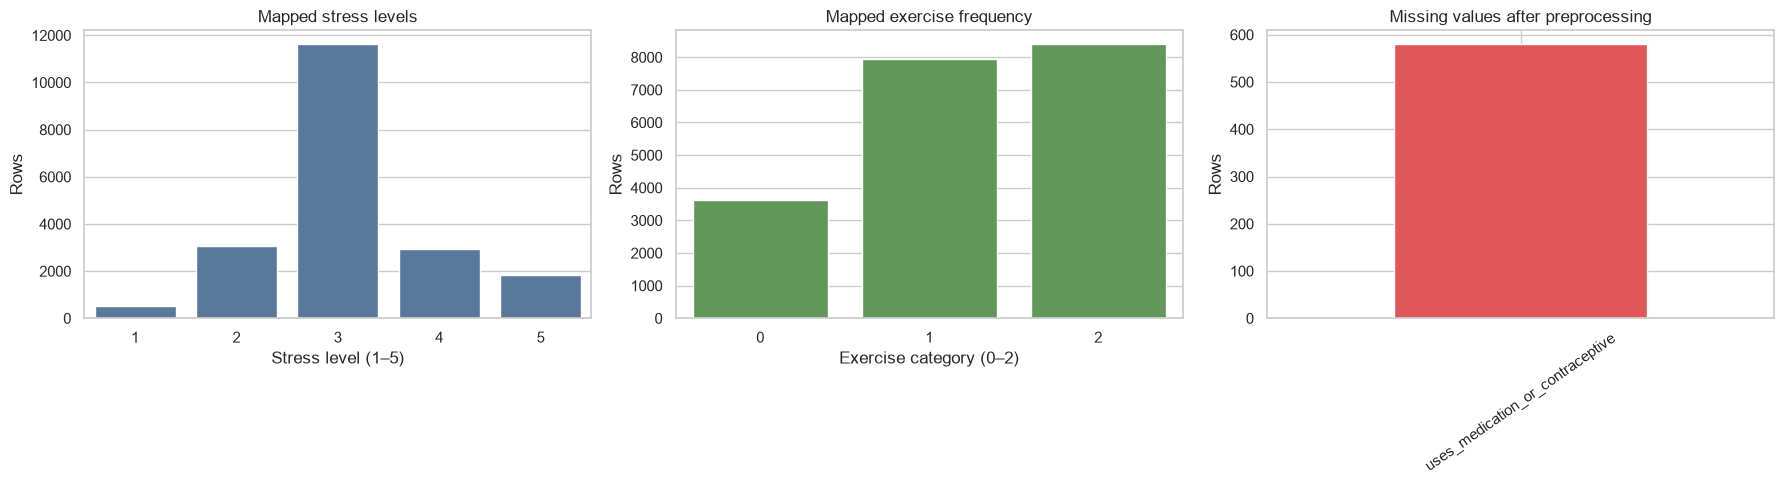

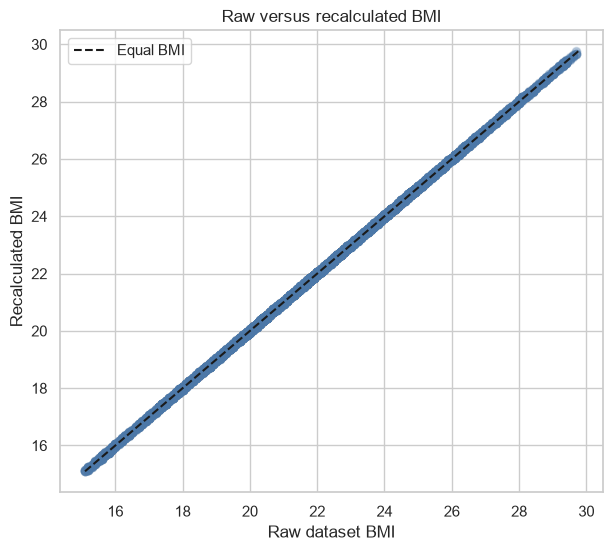

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make this visual cell safe to rerun independently after the export cell has run.
if "clean" not in globals():
    _root = Path.cwd().resolve()
    if not (_root / "data").exists():
        _root = _root.parent
    clean = pd.read_csv(_root / "processed_data" / "cleaned_dataset.csv")
    raw = pd.read_csv(_root / "data" / "calibrated_menstrual_cycle_ml_dataset.csv")
sns.set_theme(style="whitegrid", context="notebook")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(data=clean, x="stress_level", ax=axes[0], color="#4C78A8")
axes[0].set(title="Mapped stress levels", xlabel="Stress level (1–5)", ylabel="Rows")
sns.countplot(data=clean, x="exercise_frequency", ax=axes[1], color="#59A14F")
axes[1].set(
    title="Mapped exercise frequency", xlabel="Exercise category (0–2)", ylabel="Rows"
)
feature_missing = (
    clean[
        [
            "age_years",
            "menarche_age",
            "height_cm",
            "weight_kg",
            "bmi",
            "sleep_hours",
            "stress_level",
            "exercise_frequency",
            "uses_medication_or_contraceptive",
        ]
    ]
    .isna()
    .sum()
    .sort_values(ascending=False)
)
feature_missing[feature_missing.gt(0)].plot.bar(ax=axes[2], color="#E15759")
axes[2].set(title="Missing values after preprocessing", xlabel="", ylabel="Rows")
axes[2].tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()
plt.figure(figsize=(7, 6))
raw_bmi = pd.to_numeric(raw["bmi"], errors="coerce")
plt.scatter(raw_bmi, clean["bmi"], alpha=0.2, color="#4C78A8")
limits = [
    np.nanmin([raw_bmi.min(), clean["bmi"].min()]),
    np.nanmax([raw_bmi.max(), clean["bmi"].max()]),
]
plt.plot(limits, limits, "k--", label="Equal BMI")
plt.xlabel("Raw dataset BMI")
plt.ylabel("Recalculated BMI")
plt.title("Raw versus recalculated BMI")
plt.legend()
plt.show()

## Observation

The clean file retains source columns for traceability, adds app-compatible names, and does not use any whole-dataset imputation. Final modelling reads this explicit intermediate artifact.